# Crashworthiness

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from control.matlab import step, impulse, ss
from control import forced_response

def landing_gear(M1,M2,K1,K2,B):
    
    A = np.array([[0, 1, 0, 0], [-K1/M1, -B/M1, K1/M1, B/M1],[0, 0, 0, 1],[K1/M2, B/M2, -(K1+K2)/M2, -B/M2]])
    
    B = np.array([[0],[0],[0],[1/M2]])
    
    C = np.array([[1, 0, 0, 0]])
    
    D = np.array([[0]])
    
    return ss(A,B,C,D)


<AxesSubplot:>

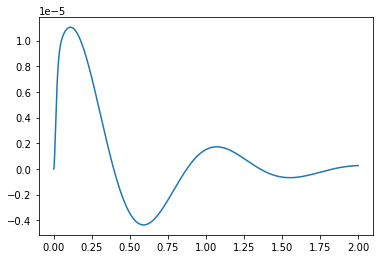

In [10]:
M1 = 1930   #airplane mass  [kg]
M2 = 50     # mass of 2 wheels (rear set)  -  research wheel mass - no data
K1 = 100000            #variable
K2 = 535323.6 # [N/m]   -   https://www.aircraftdesigns.com/design/gyroplanes/landing-gear-loads/
B = 10000   # [N/(m/s)]    #variable
# change K1 and B

sys = landing_gear(M1, M2, K1, K2, B)

#y1, t = step(H, t)       
y, t = impulse(sys, np.arange(0, 2, 0.001))
sns.lineplot(x=t, y=y)

$\vec{x} = [y_G, \alpha, \beta, \dot{y}_G, \dot{\alpha}, \dot{\beta}]^T$

$\vec{u} = [0, 0, 0, f(t), 0, 0]^T$

$\dot{\vec{x}} = A \cdot \vec{x} + B \cdot \vec{u}$

$\vec{y} = C \cdot \vec{x} + D \cdot \vec{u}$

In [45]:
import control.matlab as c

def GearSystem(K, C, M, d, l1, l2, uk):
    (k1, k2, k3), (c1, c2, c3), (m, Jx, Jz) = K, C, M

    unknown = {'yG': [1, 0, 0], 'alpha': [0, 1, 0], 'beta': [0, 0, 1]}[uk]

    d3 = np.sqrt(l2 ** 2 - 0.25 * l1 ** 2) - d
    print(d3)

    SFs = -(1/m) * np.array([k1 + k2 + k3, 0.5 * l1 * (k1 - k2), d * (k1 + k2) - d3 * k3,
                            c1 + c2 + c3, 0.5 * l1 * (c1 - c2), d * (c1 + c2) - d3 * c3])

    SMx = -(1/Jx) * np.array([0.5 * l1 * (k1 - k2), 0.25 * l1 ** 2 * (k1 + k2), 0,
                             0.5 * l1 * (c1 - c2), 0.25 * l1 ** 2 * (c1 + c2), 0])

    SMz = -(1/Jz) * np.array([d * (k1 + k2) - d3 * k3, 0.5 * l1 * d * (k1 - k2), d*d * (k1 + k2) - d3*d3 * k3,
                             d * (c1 + c2) - d3 * c3, 0.5 * l1 * d * (c1 - c2), d*d * (c1 + c2) - d3*d3 * c3])

    A = np.array([[0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1],
                   SFs, SMx, SMz])

    B = np.array([[0, 0, 0, -1/m, 0, 0]]).T

    C = np.array([unknown + [0]*3])

    D = np.array([[0]])

    return c.ss(A, B, C, D)


def SolveLandingGear(sys, imp, forc, t0, t1):
    yimp, t = c.impulse(sys, np.linspace(t0, t1, 1000))
    yimp *= imp

    yforc, t = c.step(sys, t)
    yforc *= forc

    return t, yforc + yimp

In [49]:
K = [10000000]*3
C = [0]*3
d, l1, l2 = 1, 6, 10
M = 50, 10, 10

(sys := GearSystem(K, C, M, d, l1, l2, 'yG'))

8.539392014169456


StateSpace(array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-6.00000000e+05, -0.00000000e+00,  1.30787840e+06,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-0.00000000e+00, -1.80000000e+07, -0.00000000e+00,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 6.53939201e+06, -0.00000000e+00,  7.09212160e+07,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00]]), array([[ 0.  ],
       [ 0.  ],
       [ 0.  ],
       [-0.02],
       [ 0.  ],
       [ 0.  ]]), array([[1., 0., 0., 0., 0., 0.]]), array([[0.]]))

<AxesSubplot:>

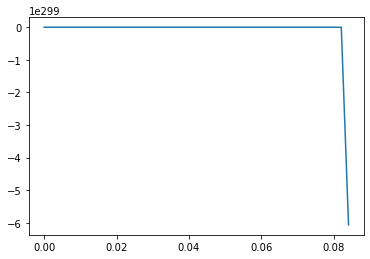

In [50]:
imp, forc = 5, 100 # N*s, N

t, y = SolveLandingGear(sys, imp, forc, 0, 2)
sns.lineplot(x=t, y=y)